In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import h5py 
import sys
import data_analysis.mea_analysis as mea
from tqdm import tqdm
from pathlib import Path
import cv2

In [ ]:
BRW_BASE_FOLDER = Path("/media/ferdinand-forberger/RawDataBackUp")
MAIN_FOLDER = Path("/media/ferdinand-forberger/Seagate Portable Drive")
GRAPH_METRICS_PATH = MAIN_FOLDER / "graph_metrics.xlsx"

df_overview = mea.get_overview(MAIN_FOLDER)
df_overview = df_overview[df_overview["sles_saved"]==True]
df_overview.reset_index(inplace=True, drop=True)
df_overview["image_path"]= df_overview["folder_path"].astype(str) + "/org_image.png"
df_overview["mask_path"] = df_overview["folder_path"].astype(str) + "/mask.png"

#get metadata file to have info about which slice belongs to which group
df_metadata = pd.read_excel("/media/ferdinand-forberger/RawDataBackUp/meta_data_file.xlsx")
df_metadata["folder"] = df_metadata["animal_number"].astype(str) + "_" + df_metadata["slice_number"].astype(str)
df_overview = pd.merge(df_overview, df_metadata, left_on="folder", right_on="folder", how="left")
df_overview["sttc_path"] = df_overview["folder_path"] / "sttc.npy"

In [3]:
def unit_to_amplitude(unit, units, amplitudes):
    mask = units == unit
    mean_apl = np.mean(amplitudes[mask])
    return mean_apl if not np.isnan(mean_apl) else 0

In [ ]:

def calculate_min_distances_to_tumor(tumor_coords, estimated_sle_origins):
    
    tumor_points_xy = np.vstack((tumor_coords[1], tumor_coords[0])).T

    distance_matrix = cdist(estimated_sle_origins, tumor_points_xy, 'euclidean')

    min_distances = np.min(distance_matrix, axis=1)

    return min_distances


In [5]:
aligned_onset_maps = np.load("data/aligned_origins_maps.npy")

In [6]:
distance_metrics = {"Onset_distances_mm" : {},
                    "Df" : 
                    {}}

for i, row in tqdm(df_overview.iterrows(), total=len(df_overview)):

    tumor_path = Path(row["folder_path"]) / "tumor.png"
    if not tumor_path.exists():
        continue
    else:
        print(f"Found tumor path: {tumor_path}")
    #json_path = row["json_path"]
    st_df, st, clu, best_cha_st, vectorized_map, amplitudes= mea.get_stdf(parent_folder_path=row["folder_path"],
                                                                    return_amplitudes=True)
    st_df = st_df.loc[st_df["num_spikes"] > 100]
    st_df["freq"] = st_df["num_spikes"] / 600
    st_df["amplitude"] = st_df["clu"].apply(lambda u: unit_to_amplitude(u, clu, amplitudes))
    st_df_temp = st_df.drop_duplicates(subset=["chan_best"], keep="first")

    burst_json_path = Path(row["folder_path"]) / "burst_params.json"
    NBs = np.load(row["sle_path"])
    res = mea.filter_spikes_find_origin(sles=NBs,
                                                st=st,
                                                clu=clu,
                                                cluster_to_channel_map=vectorized_map, 
                                                burst_json_path=burst_json_path, 
                                                folder_path=row["folder_path"])
    estimated_SLE_orgins, first_spikes, unique_chans_list, filtered_first_spikes, filtered_chans, chan_subsets = res


    

    tumor_img = plt.imread(tumor_path)
    tumor_img = cv2.resize(tumor_img, (64, 64), interpolation=cv2.INTER_NEAREST)
    tumor_img = np.sum(tumor_img, axis=2)
    tumor_img[tumor_img > 0] = 1

    tumor_coords = np.array(np.where(tumor_img > 0))
    tumor_y, tumor_x = tumor_coords

    min_distances = calculate_min_distances_to_tumor(tumor_coords, estimated_SLE_orgins)
    min_distances_mm = min_distances / 64 * 3.8
    distance_metrics["Onset_distances_mm"][row["folder"]] = min_distances_mm

    st_df["x_coords"], st_df["y_coords"] = mea.chans_to_coords(st_df["chan_best"])
    channel_locs = np.vstack((st_df["x_coords"], st_df["y_coords"])).T
    st_df["min_distances"] = calculate_min_distances_to_tumor(tumor_coords, channel_locs)
    st_df["min_distances_mm"] = st_df["min_distances"]/64*3.8
        
    distance_metrics["Df"][row["folder"]] = st_df[["min_distances_mm", "freq", "amplitude"]]

  0%|          | 0/22 [00:00<?, ?it/s]

Found tumor path: /media/ferdinand-forberger/Seagate Portable Drive/8561_3/tumor.png
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 408, disagreement: 0
Number of good clusters (Original): 121
Number of good clusters (Changed): 121
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 408, disagreement: 0
Number of good clusters (Original): 121
Number of good clusters (Changed): 121
-------------------------------------------------------


  5%|▍         | 1/22 [00:05<02:03,  5.89s/it]

Found tumor path: /media/ferdinand-forberger/Seagate Portable Drive/8561_5/tumor.png
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------


  9%|▉         | 2/22 [00:09<01:26,  4.35s/it]

...

 55%|█████▍    | 12/22 [00:27<00:20,  2.01s/it]

Found tumor path: /media/ferdinand-forberger/Seagate Portable Drive/8604_5/tumor.png
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 1330, disagreement: 0
Number of good clusters (Original): 470
Number of good clusters (Changed): 470
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 1330, disagreement: 0
Number of good clusters (Original): 470
Number of good clusters (Changed): 470
-------------------------------------------------------


 59%|█████▉    | 13/22 [00:39<00:36,  4.09s/it]

Found tumor path: /media/ferdinand-forberger/Seagate Portable Drive/8604_6/tumor.png
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 406, disagreement: 0
Number of good clusters (Original): 136
Number of good clusters (Changed): 136
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 406, disagreement: 0
Number of good clusters (Original): 136
Number of good clusters (Changed): 136
-------------------------------------------------------


100%|██████████| 22/22 [00:44<00:00,  2.00s/it]


In [7]:
distances_dict = {}
for key in distance_metrics["Onset_distances_mm"].keys():
    distances = distance_metrics["Onset_distances_mm"][key]
    mean_distance = np.mean(distances)
    std_distance = np.std(distances)
    distances_dict[key] = (mean_distance, std_distance)
distances_dict = pd.DataFrame.from_dict(distances_dict, columns=["Mean", "Std"], orient="index")
distances_dict.to_excel(Path("data")/ "Onset_distances_from_tumor.xlsx")

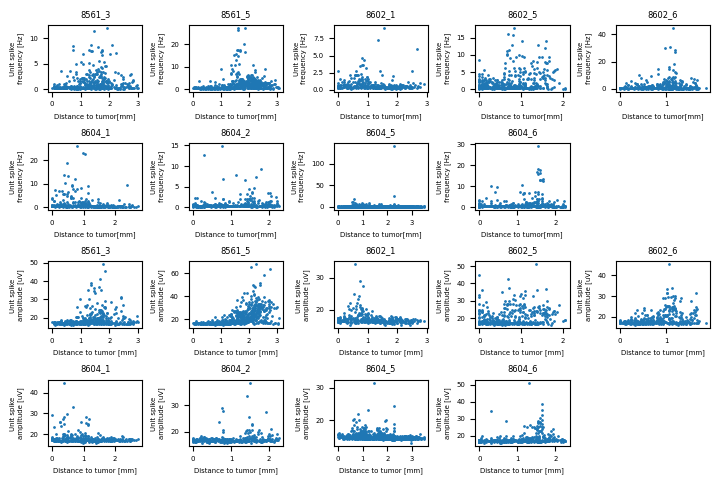

In [8]:
plt.rcParams.update({'font.size': 5})
cm = 1/2.54
fig, ax = plt.subplots(4, 5, figsize=(18*cm, 12*cm), layout="constrained")
for i, (key, df) in enumerate(distance_metrics["Df"].items()):
    r = i // 5
    c = i % 5
    ax[r, c].scatter(df["min_distances_mm"], df["freq"], s=1)
    ax[r, c].set_title(key)
    ax[r, c].set_xlabel("Distance to tumor[mm]")
    ax[r, c].set_ylabel("Unit spike\nfrequency [Hz]")


for i, key in enumerate(distance_metrics["Df"].keys()):
    i = i + 10
    r = i // 5
    c = i % 5
    ax[r, c].scatter(distance_metrics["Df"][key]["min_distances_mm"], distance_metrics["Df"][key]["amplitude"], s=1)
    ax[r, c].set_title(key)
    ax[r, c].set_xlabel("Distance to tumor [mm]")
    ax[r, c].set_ylabel("Unit spike \namplitude [uV]")

fig.delaxes(ax[1,4])
fig.delaxes(ax[3,4])
plt.savefig(Path("plots") / "Onset_distance_to_tumor_vs_freq_amplitude.png", dpi=300, bbox_inches="tight")
plt.show()
